## Практическое задание №2
#### по дисциплине "Введение в анализ данных"

*Работу выполнил*: Евсеев Григорий, 3826Б1ПМад1

Работа выполнена с использованием IDE Visual Studio Code.

### Часть 1.

Нахождение объема выборки

In [1]:
import xlrd

book = xlrd.open_workbook("02_Онлайн_продажи_2.xlsx")
sheet = book.sheet_by_index(0)  # данные из листа по индексу

event_types = [] # список всех наблюдаемых событий
prices = [] # список стоимостей всех продуктов
prices_on_event = {} # словарь стоимостей продуктов по типу событий

sample_size = sheet.nrows - 1

for i in range(sample_size):
    event_types.append(sheet.cell_value(i + 1, 1))
    prices.append(float(sheet.cell_value(i + 1, 5)))
    if (prices_on_event.get(sheet.cell_value(i + 1, 1)) == None):
        prices_on_event[sheet.cell_value(i + 1, 1)] = []
    prices_on_event[sheet.cell_value(i + 1, 1)].append(float(sheet.cell_value(i + 1, 5)))

from collections import Counter
event_types_counter = Counter(event_types)
event_types_counter


Counter({'view': 267, 'remove_from_cart': 123, 'cart': 87, 'purchase': 23})

Построим столбчатую диаграмму (гистограмму) средствами библиотеки matplotlib

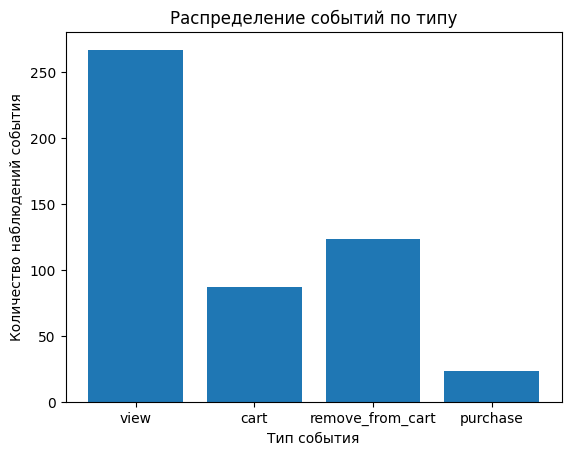

In [2]:
import matplotlib.pyplot as plt

plt.bar(event_types_counter.keys(), event_types_counter.values())
plt.xlabel("Тип события")
plt.ylabel("Количество наблюдений события")
plt.title("Распределение событий по типу")
plt.show()

Построим гистограмму для величин $\xi$:

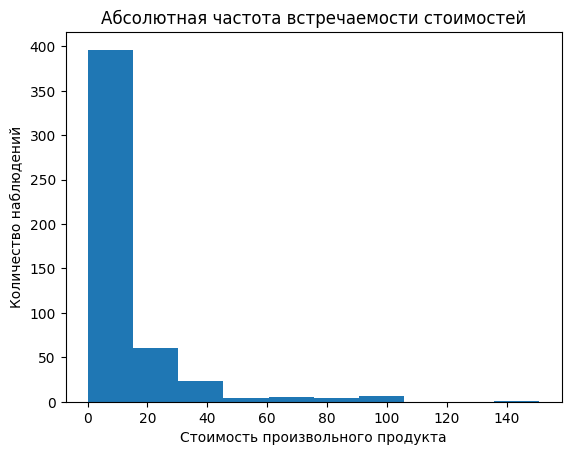

In [3]:
prices.sort()
min_price = prices[0]
max_price = prices[-1]
price_scope = max_price - min_price
prices_stat_series = Counter(prices)

x = plt.hist(prices) # группированный статистический ряд, информационная совокупность

plt.xlabel("Стоимость произвольного продукта")
plt.ylabel("Количество наблюдений")
plt.title("Абсолютная частота встречаемости стоимостей")
plt.show()

In [4]:
x

(array([396.,  60.,  23.,   4.,   5.,   4.,   7.,   0.,   0.,   1.]),
 array([  0.22 ,  15.277,  30.334,  45.391,  60.448,  75.505,  90.562,
        105.619, 120.676, 135.733, 150.79 ]),
 <BarContainer object of 10 artists>)

Text(0.5, 1.0, 'Приближение ЭФР')

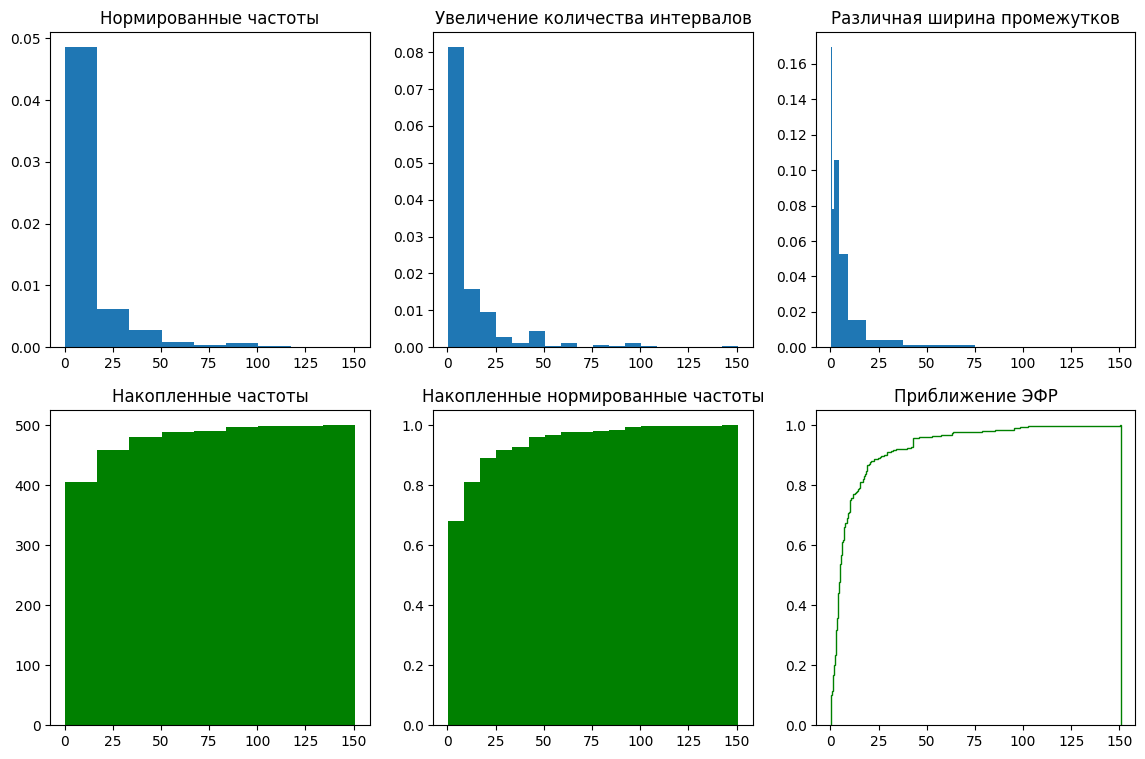

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize = (14, 9))

import math
k = int(math.log(sample_size, 2)) + 1
delta = (max_price - min_price) / k

axes[0][0].hist(prices, bins = k, density = True)
axes[0][0].set_title("Нормированные частоты")

axes[0][1].hist(prices, bins = 2*k, density = True)
axes[0][1].set_title("Увеличение количества интервалов")

def exp_borders(min, max, n):
    bord = []
    bord.append(min)
    delta = (max - min) / (2 ** n - 1)
    for i in range(n):
        bord.append(bord[i] + delta)
        delta *= 2
    return bord

axes[0][2].hist(prices, bins = exp_borders(min_price, max_price, k - 1), density = True)
axes[0][2].set_title("Различная ширина промежутков")

axes[1][0].hist(prices, bins = k, color = 'g', cumulative = True)
axes[1][0].set_title("Накопленные частоты")

axes[1][1].hist(prices, bins = 2*k, density = True, color = 'g', cumulative = True)
axes[1][1].set_title("Накопленные нормированные частоты")

axes[1][2].hist(prices, bins = sample_size, density = True, color = 'g', cumulative = True, histtype = 'step', fill = False)
axes[1][2].set_title("Приближение ЭФР")

Эмпирическая функция распределения

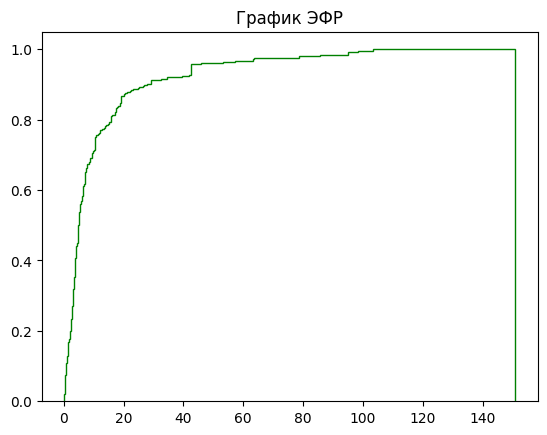

In [6]:
plt.hist(prices, bins = list(prices_stat_series.keys()), density = True, cumulative = True,
         color = 'g', histtype = 'step', fill = False)
plt.title("График ЭФР")
plt.show()

Распределения для $\xi$:

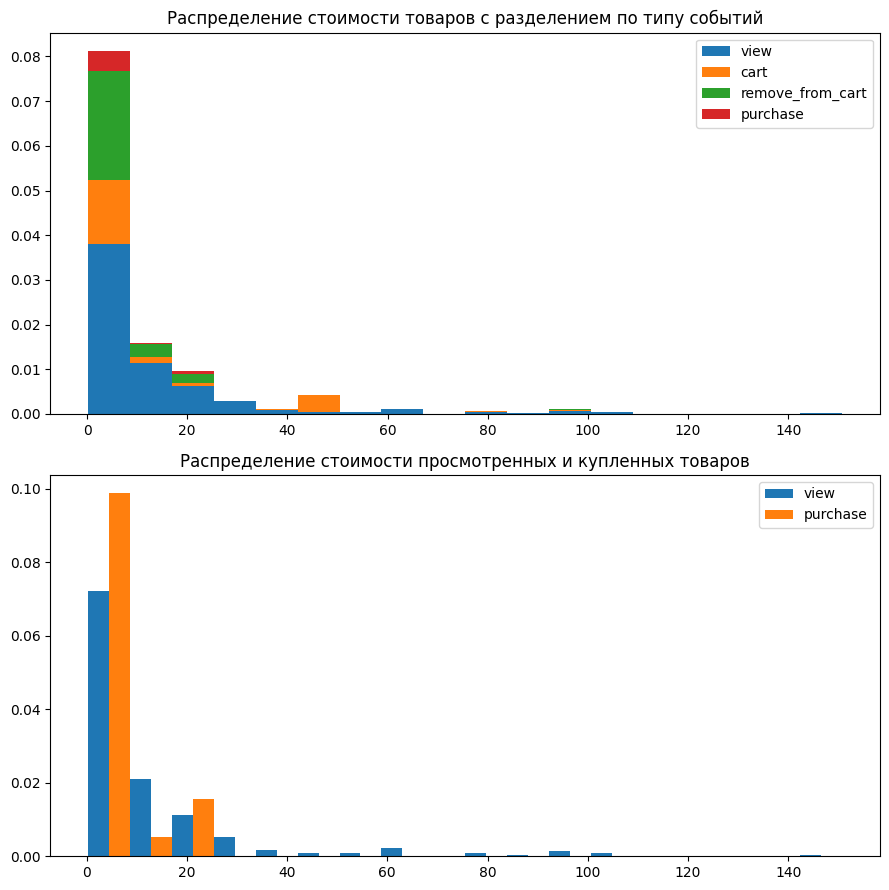

In [7]:
fig, axes = plt.subplots(2, figsize = (9, 9))
labels = ['view', 'cart', 'remove_from_cart', 'purchase']


axes[0].hist([prices_on_event['view'], prices_on_event['cart'], prices_on_event['remove_from_cart'], prices_on_event['purchase']],
             bins = 2*k, label = labels, density = True, histtype='bar', stacked = True)
axes[0].legend()
axes[0].set_title("Распределение стоимости товаров с разделением по типу событий")


axes[1].hist([prices_on_event['view'], prices_on_event['purchase']],
             bins = 2*k, label = ['view', 'purchase'], density = True, histtype='bar', rwidth = 1)
axes[1].legend()
axes[1].set_title("Распределение стоимости просмотренных и купленных товаров")


fig.tight_layout()
plt.show()

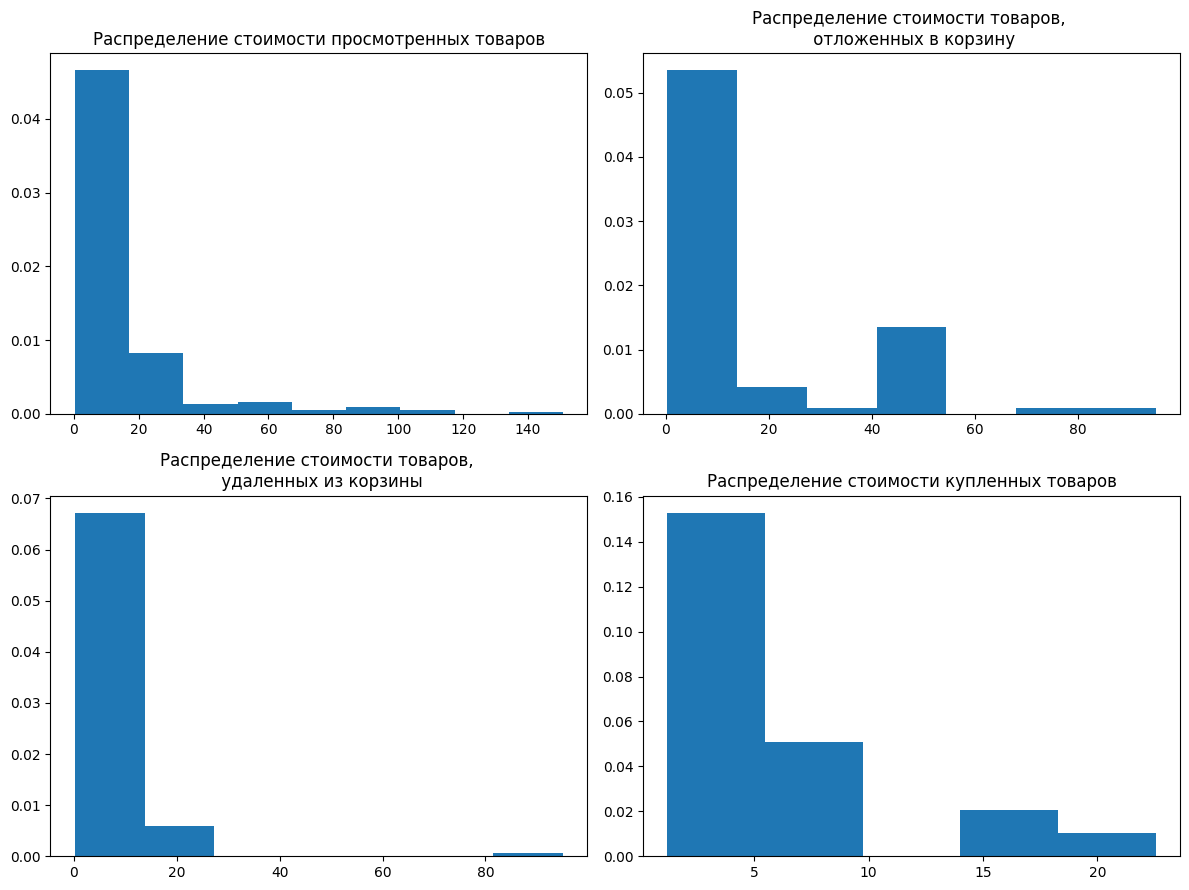

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))

axes[0][0].hist(prices_on_event['view'], bins = int(math.log(event_types_counter['view'], 2)) + 1, density = True)
axes[0][0].set_title("Распределение стоимости просмотренных товаров")


axes[0][1].hist(prices_on_event['cart'], bins = int(math.log(event_types_counter['cart'], 2)) + 1, density = True)
axes[0][1].set_title("Распределение стоимости товаров, \n отложенных в корзину")


axes[1][0].hist(prices_on_event['remove_from_cart'], bins = int(math.log(event_types_counter['remove_from_cart'], 2)) + 1, density = True)
axes[1][0].set_title("Распределение стоимости товаров, \n удаленных из корзины")

axes[1][1].hist(prices_on_event['purchase'], bins = int(math.log(event_types_counter['purchase'], 2)) + 1, density = True)
axes[1][1].set_title("Распределение стоимости купленных товаров")

fig.tight_layout()
plt.show()


При работе выдавались UserWarnings о том, что функция distplot более не рекомендуется к использованию. Для скрытия UserWarnings добавил следующее:

In [9]:
import warnings
warnings.filterwarnings('ignore')

Визуализация с использованием библиотеки $~seaborn~$

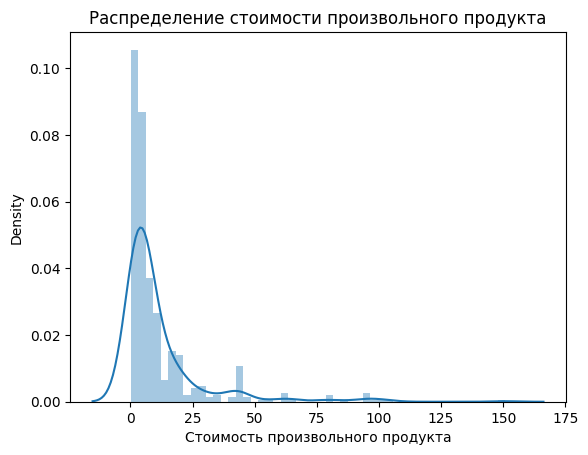

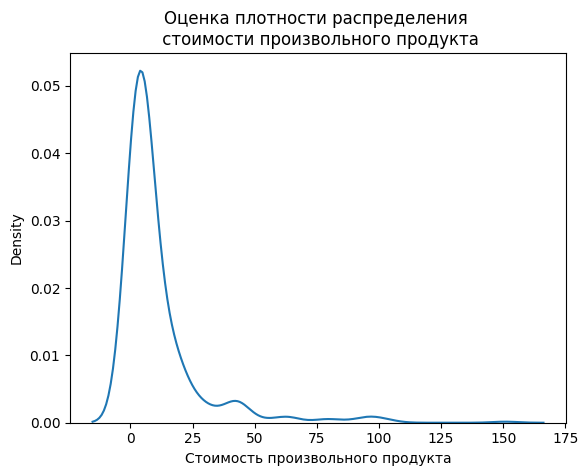

In [10]:
import seaborn as sns

sns.distplot(prices)
plt.xlabel("Стоимость произвольного продукта")
plt.title("Распределение стоимости произвольного продукта")
plt.show()

sns.distplot(prices, hist = False, kde=True)
plt.xlabel("Стоимость произвольного продукта")
plt.title("Оценка плотности распределения \n стоимости произвольного продукта")
plt.show()

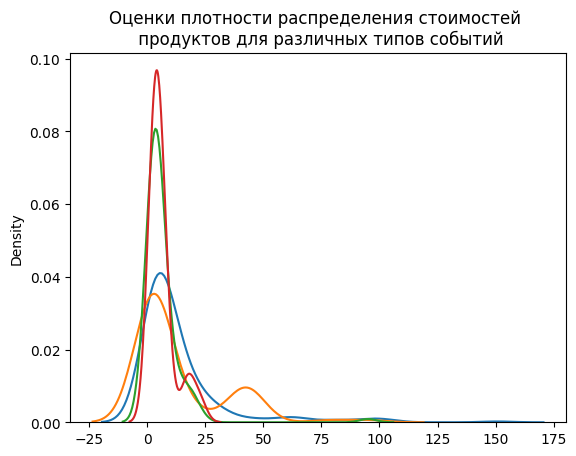

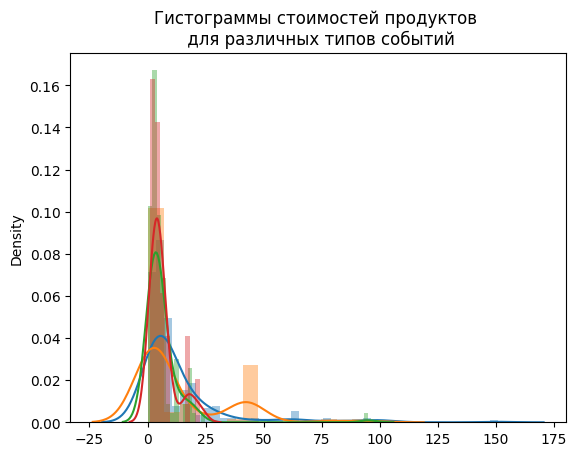

In [11]:
for type in prices_on_event.keys():
    sns.distplot(prices_on_event[type], hist = False, kde = True, label = type)
plt.title("Оценки плотности распределения стоимостей \n продуктов для различных типов событий")
plt.show()

for type in prices_on_event.keys():
    sns.distplot(prices_on_event[type], hist = True, norm_hist=True, kde = True)
plt.title("Гистограммы стоимостей продуктов \n для различных типов событий")
plt.show()

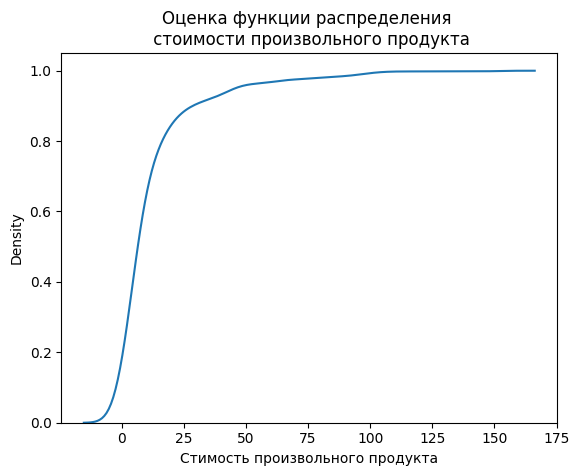

In [12]:
x = sns.kdeplot(prices, cumulative = True)
plt.xlabel("Стимость произвольного продукта")
plt.title("Оценка функции распределения \n стоимости произвольного продукта")
plt.show()

### Часть 2. 

In [13]:
import xlrd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


#### Пункт 1. Определение типа данных для каждого из столбцов

Подготовка данных, загрузка

In [14]:
book = xlrd.open_workbook('02_Автоаварии.xlsx')
sheet = book.sheet_by_index(0)

num_rows = sheet.nrows
num_cols = sheet.ncols

print("Количество строк = ", num_rows)
print("Количество столбцов = ", num_cols)

headers = sheet.row_values(0)
for i, j in enumerate(headers):
    print(f'{i}: {j}')
    

Количество строк =  5001
Количество столбцов =  37
0: ID
1: Source
2: TMC
3: Severity
4: Start_Time
5: End_Time
6: Distance(mi)
7: Description
8: Street
9: Side
10: City
11: State
12: Zipcode
13: Weather_Timestamp
14: Temperature(F)
15: Wind_Chill(F)
16: Humidity(%)
17: Pressure(in)
18: Visibility(mi)
19: Wind_Direction
20: Wind_Speed(mph)
21: Precipitation(in)
22: Weather_Condition
23: Bump
24: Crossing
25: Give_Way
26: Junction
27: No_Exit
28: Railway
29: Roundabout
30: Station
31: Stop
32: Traffic_Calming
33: Traffic_Signal
34: Turning_Loop
35: Sunrise_Sunset
36: Civil_Twilight


В таблице приведены следующие столбцы:

- `ID`: номинальный тип, уникальный номер аварии;
- `Source`: номинальный тип, источник данных;
- `TMC`: дискретный количественый тип, числовой код дорожного сообщения;
- `Severity`: порядковый тип данных, степень серьёзности аварии от 1 до 4;
- `Start_Time`: дата/воемя, начало аварии;
- `End_Time`: дата/время, конец аварии;
- `Distance(mi)`: непрерывный количественный тип, протяженность дороги в милях;
- `Description`: номинальный тип, описание;
- `Street`: номинальные данные, название улицы;
- `Side`: номинальные данные, сторона дороги;
- `City`: номинальные данные, город;
- `State`: номинальные, штат;
- `Zipcode`: номинальные, почтовый индекс;
- `Weather_Timestamp`: дата/время, момент, когда была зафикисрована погода;
- `Temperature(F)`: непр. количественные, температура воздуха;
- `Wind_Chill(F)`: непр. количественные, ощущаемая температура;
- `Humidity(%)`: непр. количественные, влажность воздуха;
- `Pressure(in)`: непр. количественные, давление;
- `Visibility(mi)`: непр. количественные, видимость дороги в милях;
- `Wind_Direction`:  номинальные, направление ветра;
- `Wind_Speed(mph)`: непр. количественные, скорость ветра;
- `Precipitation(in)`: непр. количественные, осадки;
- `Weather_Condition`: номинальные, погодные условия;
- `Bump`, `Crossing`, `Give_Way`, `Junction`, `No_Exit`, `Railway`, `Roundabout`, `Station`, `Stop`, `Traffic_Calming`, `Traffic_Signal`, `Turning_Loop`:  признаки описаны через True/False, наличие или отсутствие данного признака аварии;
 - `Sunrise_Sunset`, `Civil_Twilight`: описаны через Day/Night, номинальные признаки.

#### Пункт 2. Распределение видимости дороги $\xi$ и $\xi_1$ - $\xi_4$ по степеням серьёзности аварии

Загружаем данные:

In [15]:
visibility = []
severity = []
vis_on_sev = {1: [], 2: [], 3: [], 4: []}

for i in range(1, num_rows):
    vis = sheet.cell_value(i, 18)
    sev = sheet.cell_value(i, 3)

    if ((vis == '') or (sev == '')):
        continue

    vis = float(vis)
    sev = int(sev)
    visibility.append(vis)
    severity.append(sev)
    if sev in vis_on_sev:
        vis_on_sev[sev].append(vis)

In [16]:
sample_size = len(visibility)
print('Объём выборки кси = ', sample_size)
for k in sorted(vis_on_sev):
    print(f'Объём кси_{k} = ', len(vis_on_sev[k]))

Объём выборки кси =  4958
Объём кси_1 =  4
Объём кси_2 =  2900
Объём кси_3 =  2049
Объём кси_4 =  5


Построение гистограмм и функции распределения для $\xi$:

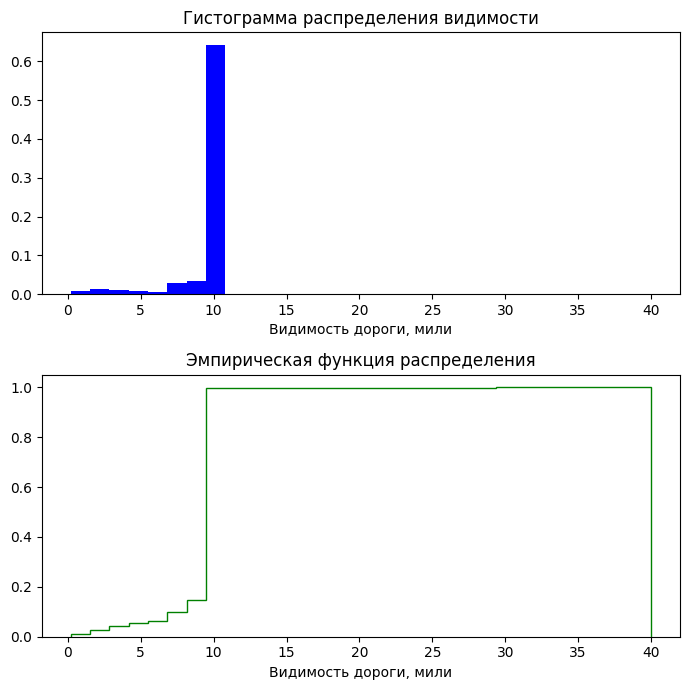

In [17]:
fig, axes = plt.subplots(2, figsize = (7, 7))

axes[0].hist(visibility, bins = 30, density = True, color = 'b')
axes[0].set_xlabel('Видимость дороги, мили')
axes[0].set_title('Гистограмма распределения видимости')

axes[1].hist(visibility, bins = 30, density = True, cumulative = True, histtype = 'step', color = 'g')
axes[1].set_xlabel('Видимость дороги, мили')
axes[1].set_title('Эмпирическая функция распределения')

fig.tight_layout()
plt.show()

Гистограммы по степеням серьезности:

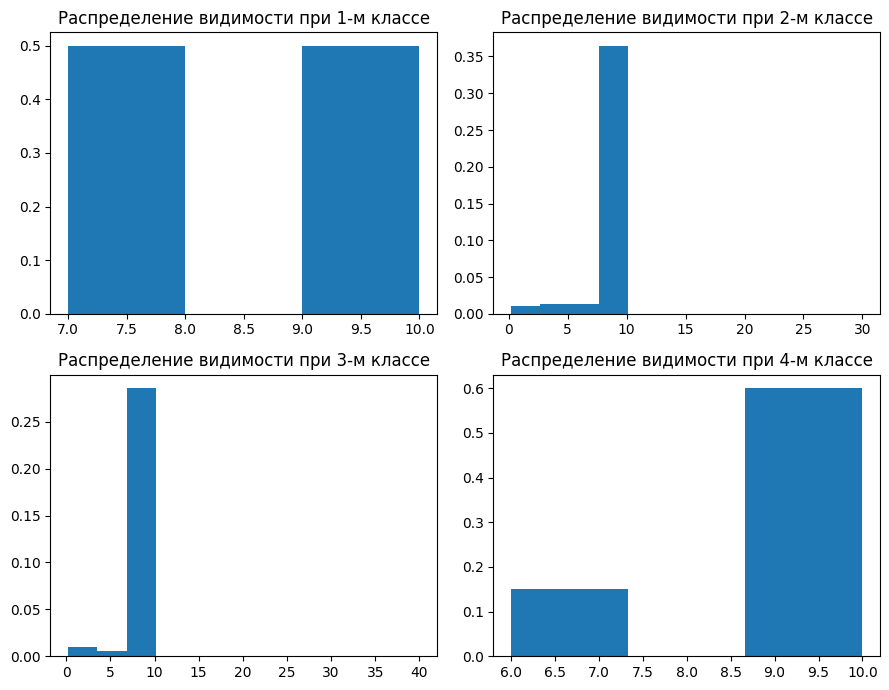

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

axes[0][0].hist(vis_on_sev[1], bins=int(math.log(len(vis_on_sev[1]), 2)) + 1, density=True)
axes[0][0].set_title("Распределение видимости при 1-м классе")

axes[0][1].hist(vis_on_sev[2], bins=int(math.log(len(vis_on_sev[2]), 2)) + 1, density=True)
axes[0][1].set_title("Распределение видимости при 2-м классе")

axes[1][0].hist(vis_on_sev[3], bins=int(math.log(len(vis_on_sev[3]), 2)) + 1, density=True)
axes[1][0].set_title("Распределение видимости при 3-м классе")

axes[1][1].hist(vis_on_sev[4], bins=int(math.log(len(vis_on_sev[4]), 2)) + 1, density=True)
axes[1][1].set_title("Распределение видимости при 4-м классе")

fig.tight_layout()
plt.show()

Эмпирические функции распределения для классов серьезности:

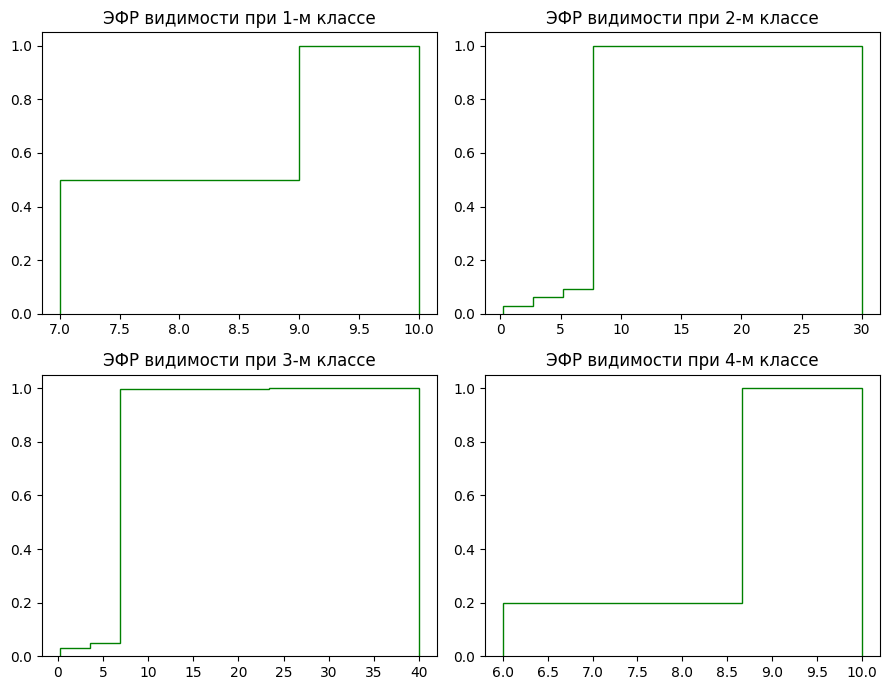

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

axes[0][0].hist(vis_on_sev[1], bins=int(math.log(len(vis_on_sev[1]), 2)) + 1,
                density=True, cumulative=True, histtype='step', color='g')
axes[0][0].set_title("ЭФР видимости при 1-м классе")

axes[0][1].hist(vis_on_sev[2], bins=int(math.log(len(vis_on_sev[2]), 2)) + 1,
                density=True, cumulative=True, histtype='step', color='g')
axes[0][1].set_title("ЭФР видимости при 2-м классе")

axes[1][0].hist(vis_on_sev[3], bins=int(math.log(len(vis_on_sev[3]), 2)) + 1,
                density=True, cumulative=True, histtype='step', color='g')
axes[1][0].set_title("ЭФР видимости при 3-м классе")

axes[1][1].hist(vis_on_sev[4], bins=int(math.log(len(vis_on_sev[4]), 2)) + 1,
                density=True, cumulative=True, histtype='step', color='g')
axes[1][1].set_title("ЭФР видимости при 4-м классе")

fig.tight_layout()
plt.show()

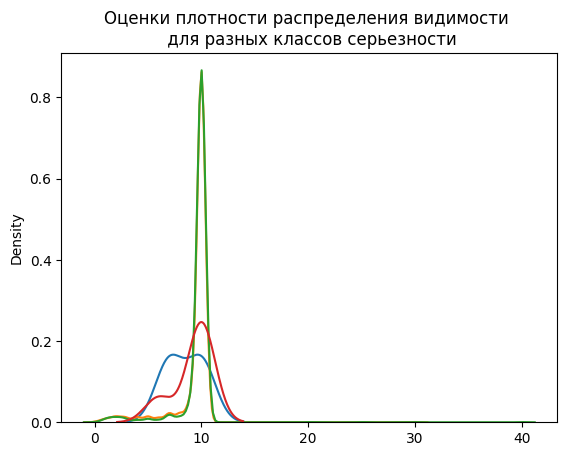

In [20]:
for sev in vis_on_sev.keys():
    sns.distplot(vis_on_sev[sev], hist=False, kde=True, label=str(sev))
plt.title("Оценки плотности распределения видимости \n для разных классов серьезности")
plt.show()

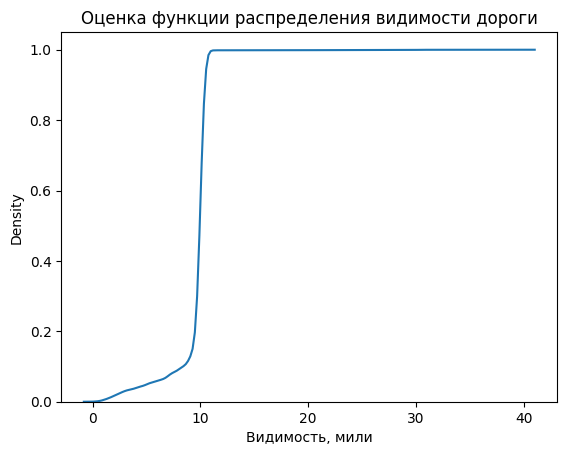

In [21]:
sns.kdeplot(visibility, cumulative=True)
plt.xlabel("Видимость, мили")
plt.title("Оценка функции распределения видимости дороги")
plt.show()

#### Пункт 3. Вариационный и статистический ряды для температуры

Загрузка значений температур:

In [22]:
temperature = []

for i in range(1, num_rows):
    t = sheet.cell_value(i, 14)
    if t == '':
        continue
    temperature.append(float(t))

print("Объем выборки =", len(temperature))

Объем выборки = 4978


Построение вариационного ряда:

In [23]:
temperature.sort()
min_temp = temperature[0]
max_temp = temperature[-1]
temp_scope = max_temp - min_temp

print("Минимум температуры: ", min_temp)
print("Максимум температуры: ", max_temp)
print("Размах: ", temp_scope)

Минимум температуры:  3.9
Максимум температуры:  106.0
Размах:  102.1


Построение статистического ряда и гистограммы группированного статистического ряда:

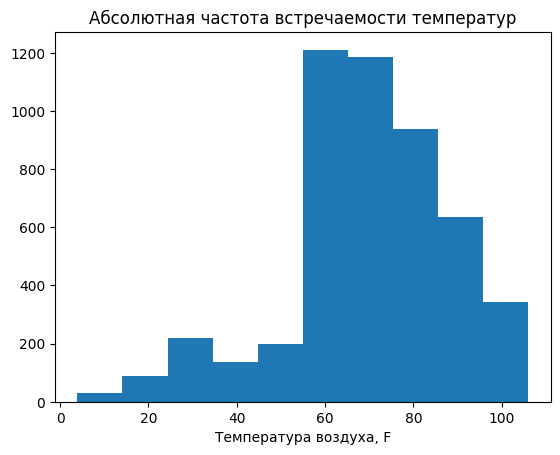

(array([  30.,   87.,  219.,  135.,  199., 1210., 1184.,  936.,  635.,
         343.]),
 array([  3.9 ,  14.11,  24.32,  34.53,  44.74,  54.95,  65.16,  75.37,
         85.58,  95.79, 106.  ]),
 <BarContainer object of 10 artists>)

In [24]:
temp_stat_series = Counter(temperature)
x = plt.hist(temperature)

plt.xlabel("Температура воздуха, F")
plt.title("Абсолютная частота встречаемости температур")
plt.show()

x

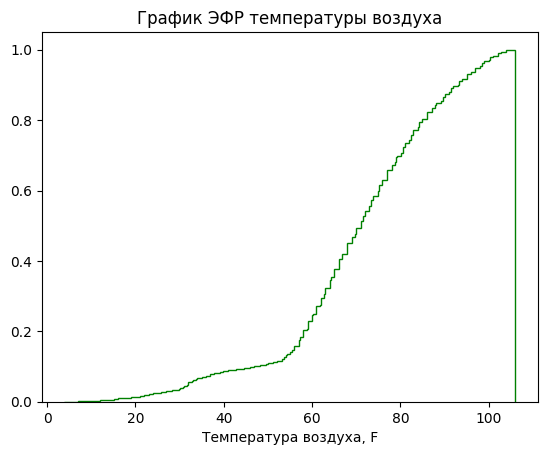

In [25]:
plt.hist(temperature, bins=list(temp_stat_series.keys()), density=True, 
         cumulative=True, color='g', histtype='step', fill=False)
plt.xlabel("Температура воздуха, F")
plt.title("График ЭФР температуры воздуха")
plt.show()

#### Пункт 4. 5 городов с наибольшим количеством автомобильных аварий

Загрузка городов, их подсчет и вывод наиболее часто встречающихся:

In [26]:
cities = []

for i in range(1, num_rows):
    c = sheet.cell_value(i, 10)
    if (c == ''):
        continue
    cities.append(c)

cities_counter = Counter(cities)
top5 = cities_counter.most_common(5)
top5

[('Sacramento', 555),
 ('Dayton', 321),
 ('San Jose', 251),
 ('Columbus', 170),
 ('Oakland', 158)]

Сбор признака `Distance` по этим пяти городам: Sacramento, Dayton, San Jose, Columbus, Oakland:

In [27]:
top5_names = []
for city, cnt in top5:
    top5_names.append(city)

dist_on_city = {}

for i in range(1, num_rows):
    city = sheet.cell_value(i, 10)
    dist = sheet.cell_value(i, 6)
    if ((city == '') or (dist == '')):
        continue
    if city in top5_names:
        if dist_on_city.get(city) == None:
            dist_on_city[city] = []
        dist_on_city[city].append(float(dist))

Построение графиков ЭФР Distance для 5 городов:

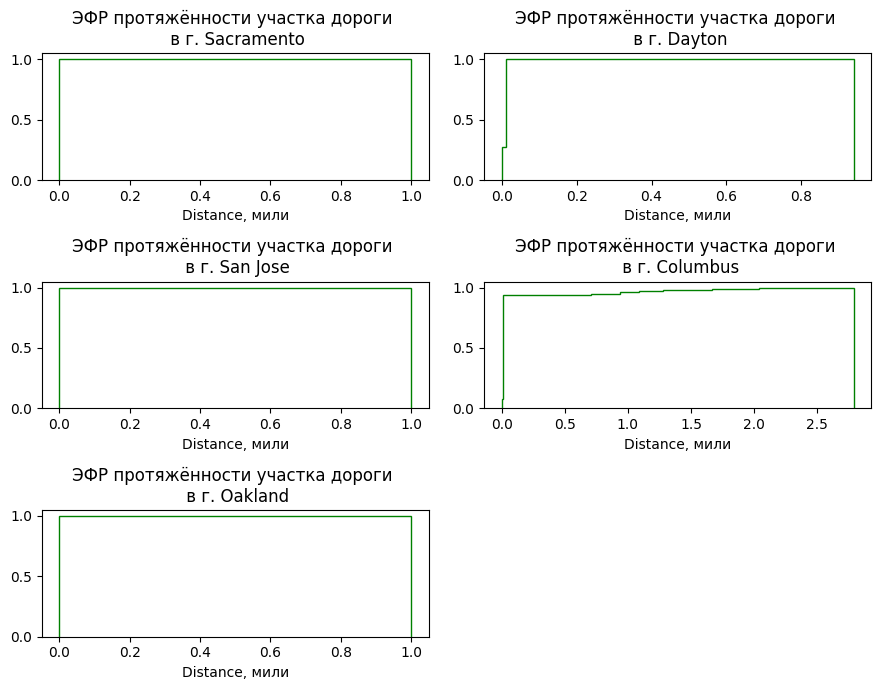

In [28]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 7))

for idx, (city, _) in enumerate(top5):
    row, col = divmod(idx, 2)
    data = dist_on_city[city]
    bins = sorted(set(data))
    
    if len(bins) < 2:   # добавил для построения графиков ЭФР трех городов в первой колонке; иначе графики отображаются
        bins = [bins[0] - 1e-12, bins[0] + 1]

    axes[row][col].hist(data, bins=bins, density=True, cumulative=True,
                        histtype='step', fill=False, color='g')
    axes[row][col].set_title(f"ЭФР протяжённости участка дороги \n в г. {city}")
    axes[row][col].set_xlabel("Distance, мили")

fig.delaxes(axes[2][1])
fig.tight_layout()
plt.show()